# Análise de Market Twin OCDE

A ideia geral desse notebook é comparar países a partir da evolução de indicadores do setor de software ao longo do tempo. Em vez de olhar apenas um ano isolado, o notebook considera trajetórias entre 2010 e 2022. Isso permite responder perguntas como: quais países têm mercados de software parecidos? Quais países possuem trajetórias atípicas? A Polônia recente se parece com quais países em períodos anteriores? A semelhança aparece por escala econômica, por estrutura produtiva, ou pelas duas coisas?

O notebook usa principalmente técnicas de **aprendizado não supervisionado**. Isso significa que não existe uma variável-alvo previamente definida, como em um modelo supervisionado de previsão. O objetivo aqui é descobrir padrões, agrupamentos e proximidades entre países a partir dos dados disponíveis.

O fluxo geral é:

```text
bases corrigidas da OCDE
→ criação de escala robusta para modelagem
→ construção de trajetórias país × ano × indicador
→ clustering K-Means
→ clustering temporal com DTW
→ comparação entre agrupamentos
→ estágios de maturidade
→ Market Twin amplo e estrutural
→ análise de crescimento com CAGR
→ interpretação econômica dos resultados
```

Duas bases são carregadas no início:

- `dados_ocde_preparado_corrigido.csv`: mantém os valores em escala real/original. Ela é usada para interpretação econômica, gráficos de trajetória e cálculo de crescimento.
- `dados_ocde_normalizado_corrigido.csv`: mantém a versão padronizada gerada no notebook de preparação. Ela é carregada por rastreabilidade, mas esta versão do notebook recalcula internamente uma escala mais robusta para modelagem.

A principal melhoria desta versão é a criação de uma representação interna com `log1p + RobustScaler`. Isso reduz a influência de países extremamente atípicos na escala dos indicadores. Na versão anterior, a normalização global com `StandardScaler` podia deixar a maioria dos países comprimida porque alguns casos de produtividade muito alta afetavam a média e o desvio-padrão.

Neste notebook, a Polônia (`POL`) é usada como país de referência para a análise de Market Twin. Porém, as etapas de clustering, DTW, maturidade e convergência consideram todos os países disponíveis na base.


---

## 0. Bibliotecas, parâmetros e configuração geral

Esta primeira célula importa as bibliotecas usadas no notebook e define parâmetros globais. Esses parâmetros controlam a reprodutibilidade dos modelos, a lista de indicadores utilizados e o país de referência da análise.

Os indicadores principais são:

- `ENTR`: número de empresas no setor de software/informação;
- `TUTT`: valor econômico agregado, turnover ou produção do setor;
- `EMPE`: número de pessoas empregadas;
- `PROD`: produtividade, calculada como `TUTT / EMPE`;
- `TAMANHO_MEDIO`: tamanho médio das empresas, calculado como `EMPE / ENTR`.

O notebook também separa dois indicadores estruturais:

```text
PROD
TAMANHO_MEDIO
```

Esses dois indicadores são chamados de estruturais porque descrevem mais a forma de organização do mercado do que o tamanho absoluto do país. Eles são especialmente importantes na análise de maturidade e no Market Twin estrutural.

A variável:

```python
PAIS_REFERENCIA = "POL"
```

define que a análise de Market Twin será feita tomando a Polônia como caso de referência. Se o grupo quiser analisar outro país no futuro, basta trocar esse código por outro país presente na base, como `BRA`, `DEU`, `ITA`, `FRA`, `NLD` etc.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
N_INIT = 20

INDICADORES = ["ENTR", "TUTT", "EMPE", "PROD", "TAMANHO_MEDIO"]
INDICADORES_ESTRUTURAIS = ["PROD", "TAMANHO_MEDIO"]

PAIS_REFERENCIA = "POL"

JANELAS_TWIN = [
    (2010, 2012, "2010-2012"),
    (2013, 2015, "2013-2015"),
    (2016, 2018, "2016-2018"),
    (2019, 2022, "2019-2022"),
]

JANELA_REFERENCIA = (2019, 2022)

---

## 1. Carregamento das bases corrigidas

Esta etapa lê os arquivos gerados pelo notebook de preparação de dados:

```text
dados_ocde_preparado_corrigido.csv
dados_ocde_normalizado_corrigido.csv
```

A base preparada é a mais importante para interpretação econômica, porque contém os valores reais dos indicadores. É nela que conseguimos interpretar frases como “a produtividade aumentou”, “o número de empresas cresceu” ou “o tamanho médio das firmas caiu”.

A base normalizada é carregada para manter compatibilidade com o pipeline anterior e para deixar claro que o primeiro notebook também gerou uma versão padronizada. Porém, nesta versão aprimorada, os modelos não dependem diretamente dessa normalização. Em vez disso, o notebook constrói uma nova escala interna, mais robusta a outliers.

A função `localizar_arquivo` serve para tornar o notebook mais flexível no Colab. Ela tenta encontrar os arquivos mesmo se o Colab tiver renomeado o arquivo com sufixos como `(1)`.

Depois do carregamento, o notebook valida se as colunas necessárias existem e se os tipos das variáveis estão adequados. Essa verificação é importante porque evita que a análise siga silenciosamente com uma base incorreta.


In [2]:
def localizar_arquivo(candidatos, pasta="."):
    pasta = Path(pasta)

    for nome in candidatos:
        caminho = pasta / nome
        if caminho.exists():
            return caminho

    csvs = sorted(pasta.glob("*.csv"))
    for candidato in candidatos:
        chave = candidato.lower().replace(".csv", "").replace(" ", "")
        for csv in csvs:
            nome_limpo = csv.name.lower().replace(".csv", "").replace(" ", "")
            if chave in nome_limpo:
                return csv

    raise FileNotFoundError(
        f"Não encontrei nenhum dos arquivos esperados: {candidatos}. "
        "Execute primeiro o notebook 01_preparacao_dados_ocde.ipynb ou coloque as bases corrigidas nesta pasta."
    )


ARQUIVO_PREPARADO = localizar_arquivo([
    "dados_ocde_preparado_corrigido.csv",
    "dados_ocde_preparado_corrigido(1).csv",
    "dados_ocde_preparado_corrigido (1).csv",
])

ARQUIVO_NORMALIZADO = localizar_arquivo([
    "dados_ocde_normalizado_corrigido.csv",
    "dados_ocde_normalizado_corrigido(1).csv",
    "dados_ocde_normalizado_corrigido (1).csv",
])

print(f"Base preparada carregada: {ARQUIVO_PREPARADO}")
print(f"Base normalizada carregada: {ARQUIVO_NORMALIZADO}")

df = pd.read_csv(ARQUIVO_PREPARADO)
df_norm_original = pd.read_csv(ARQUIVO_NORMALIZADO)

# Padronização defensiva de tipos
for base_df in [df, df_norm_original]:
    base_df["Pais"] = base_df["Pais"].astype(str).str.strip()
    base_df["Ano"] = pd.to_numeric(base_df["Ano"], errors="coerce").astype(int)

    for col in INDICADORES:
        base_df[col] = pd.to_numeric(base_df[col], errors="coerce")

colunas_necessarias = {"Pais", "Ano", *INDICADORES, "Flag_Outlier_Prod"}
faltantes_preparada = colunas_necessarias.difference(df.columns)
faltantes_normalizada = {"Pais", "Ano", *INDICADORES}.difference(df_norm_original.columns)

if faltantes_preparada:
    raise ValueError(f"Colunas ausentes na base preparada: {sorted(faltantes_preparada)}")

if faltantes_normalizada:
    raise ValueError(f"Colunas ausentes na base normalizada: {sorted(faltantes_normalizada)}")

print("\nResumo da base preparada:")
print(f"Shape: {df.shape}")
print(f"Países: {df['Pais'].nunique()}")
print(f"Anos: {int(df['Ano'].min())}–{int(df['Ano'].max())}")

print("\nResumo de ausências nas colunas de modelagem:")
print(df[INDICADORES].isna().sum())

print("\nResumo de zeros nas colunas de modelagem:")
print((df[INDICADORES] == 0).sum())

display(df.head())

Base preparada carregada: dados_ocde_preparado_corrigido.csv
Base normalizada carregada: dados_ocde_normalizado_corrigido.csv

Resumo da base preparada:
Shape: (444, 10)
Países: 35
Anos: 2010–2022

Resumo de ausências nas colunas de modelagem:
ENTR             0
TUTT             0
EMPE             0
PROD             0
TAMANHO_MEDIO    0
dtype: int64

Resumo de zeros nas colunas de modelagem:
ENTR             0
TUTT             0
EMPE             0
PROD             0
TAMANHO_MEDIO    0
dtype: int64


,Pais,Ano,ENTR,TUTT,EMPE,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado,Flag_Outlier_Prod,PROD,TAMANHO_MEDIO
0,AUT,2010,12849.0,7355.600098,41793.0,0,0,0,0.176001,3.252627
1,AUT,2011,13227.0,8683.399902,45761.0,0,0,0,0.189755,3.459666
2,AUT,2012,13545.0,9283.199707,48444.0,0,0,0,0.191627,3.576523
3,AUT,2013,13863.0,10036.300049,50439.0,0,0,0,0.198979,3.638390
4,AUT,2014,14236.0,10808.200195,53606.0,0,0,0,0.201623,3.765524


---

## 2. Criação da base de modelagem robusta: `log1p + RobustScaler`

Esta é uma das etapas metodológicas mais importantes do notebook.

A base preparada contém valores reais, mas esses valores não são ideais para calcular distâncias diretamente. Isso acontece porque os indicadores estão em escalas muito diferentes. Por exemplo, `ENTR` e `EMPE` podem ter valores muito altos, enquanto `PROD` e `TAMANHO_MEDIO` podem estar em escalas bem menores. Se comparássemos os países usando os valores brutos, as variáveis de maior magnitude dominariam as distâncias.

Uma solução comum seria aplicar `StandardScaler`, mas ele usa média e desvio-padrão. O problema é que alguns países possuem produtividade muito atípica, e esses outliers podem distorcer a média e o desvio-padrão. Quando isso acontece, a maioria dos países fica comprimida em uma faixa pequena da escala.

Por isso, esta versão usa uma transformação em duas etapas:

```text
1. log1p(x) = log(1 + x)
2. RobustScaler
```

A transformação `log1p` reduz a assimetria dos dados econômicos. Valores muito grandes continuam sendo grandes, mas deixam de dominar tanto a escala. O `RobustScaler` usa mediana e intervalo interquartil, sendo menos sensível a valores extremos do que o `StandardScaler`.

Além disso, o ajuste do scaler é feito preferencialmente usando apenas os países que não foram marcados como outliers de produtividade. Depois, a transformação é aplicada a todos os países, inclusive os outliers. Isso evita que países muito atípicos ditem a escala dos demais, mas mantém esses países na análise.

Em termos simples: esta etapa cria uma base mais justa para comparar países.


In [3]:
def criar_base_modelagem_robusta(dados, indicadores, coluna_outlier="Flag_Outlier_Prod"):
    dados_modelo = dados[["Pais", "Ano", coluna_outlier]].copy()

    X_log = np.log1p(dados[indicadores].astype(float))

    if coluna_outlier in dados.columns:
        mascara_fit = dados[coluna_outlier].eq(0)
    else:
        mascara_fit = pd.Series(True, index=dados.index)

    scaler = RobustScaler()
    scaler.fit(X_log.loc[mascara_fit, indicadores])

    X_scaled = scaler.transform(X_log[indicadores])

    for i, col in enumerate(indicadores):
        dados_modelo[col] = X_scaled[:, i]

    return dados_modelo, scaler


df_model, scaler_modelagem = criar_base_modelagem_robusta(df, INDICADORES)

print("Base de modelagem robusta criada.")
print(f"Shape: {df_model.shape}")
print("\nAusências na base de modelagem:")
print(df_model[INDICADORES].isna().sum())

display(df_model.head())

Base de modelagem robusta criada.
Shape: (444, 8)

Ausências na base de modelagem:
ENTR             0
TUTT             0
EMPE             0
PROD             0
TAMANHO_MEDIO    0
dtype: int64


,Pais,Ano,Flag_Outlier_Prod,ENTR,TUTT,EMPE,PROD,TAMANHO_MEDIO
0,AUT,2010,0,0.083421,-0.126233,-0.081754,-0.025647,-0.605831
1,AUT,2011,0,0.097763,-0.076185,-0.041794,0.049159,-0.499240
2,AUT,2012,0,0.109515,-0.056041,-0.016693,0.059273,-0.441242
3,AUT,2013,0,0.120994,-0.032517,0.001086,0.098838,-0.411133
4,AUT,2014,0,0.134127,-0.010170,0.027914,0.113009,-0.350502


---

## 3. Construção do tensor país × ano × indicador

Depois de criar a base de modelagem robusta, o notebook organiza os dados em um tensor tridimensional.

O formato é:

```text
país × ano × indicador
```

Neste projeto, a estrutura esperada é aproximadamente:

```text
35 países × 13 anos × 5 indicadores
```

Essa organização é necessária porque vários métodos usados depois trabalham com trajetórias temporais. Em vez de comparar apenas médias ou valores finais, o notebook compara o comportamento dos países ao longo do tempo.

Cada país passa a ser representado por uma sequência anual dos cinco indicadores. Se algum ano estiver ausente para determinado país, o código faz interpolação e preenchimento defensivo. Na prática, a base preparada já vem praticamente pronta, mas esse cuidado garante que o tensor final não contenha `NaN`.

A vantagem dessa estrutura é que ela permite transformar a pergunta “quais países são parecidos?” em uma pergunta mais rica:

> Quais países tiveram trajetórias parecidas no setor de software ao longo do tempo?


In [4]:
PAISES = sorted(df_model["Pais"].unique())
ANOS = list(range(int(df_model["Ano"].min()), int(df_model["Ano"].max()) + 1))


def construir_tensor(dados, paises, anos, indicadores):
    series = []

    for pais in paises:
        dp = (
            dados[dados["Pais"] == pais]
            .set_index("Ano")
            .reindex(anos)
            .sort_index()
        )

        valores = dp[indicadores].copy()
        valores = valores.interpolate(method="linear", limit_direction="both")
        valores = valores.ffill().bfill()

        series.append(valores.values)

    tensor = np.array(series, dtype=float)
    return tensor


tensor = construir_tensor(df_model, PAISES, ANOS, INDICADORES)
N_PAISES, N_ANOS, N_INDICADORES = tensor.shape

print(f"Tensor criado: {tensor.shape}")
print(f"Países: {N_PAISES}")
print(f"Anos: {N_ANOS}")
print(f"Indicadores: {N_INDICADORES}")
print(f"NaN no tensor: {np.isnan(tensor).sum()}")

Tensor criado: (35, 13, 5)
Países: 35
Anos: 13
Indicadores: 5
NaN no tensor: 0


---

## 4. Clustering de trajetórias com K-Means

Nesta etapa, o notebook aplica o algoritmo K-Means para agrupar países com trajetórias semelhantes.

Para usar K-Means, cada país precisa ser representado como um vetor. Como temos 13 anos e 5 indicadores, cada país é transformado em um vetor com:

```text
13 × 5 = 65 atributos
```

Esse vetor resume a trajetória do país ao longo do período analisado. O K-Means tenta formar grupos de países que estejam próximos nesse espaço de 65 dimensões.

O notebook testa diferentes valores de `k`, isto é, diferentes números de clusters. Para avaliar os resultados, são usados dois diagnósticos:

- **Inércia**: mede o quanto os pontos estão próximos do centro do seu cluster. É usada no gráfico do cotovelo.
- **Silhouette**: mede o quanto os clusters estão separados e coesos. Valores mais altos geralmente indicam agrupamentos mais bem definidos.

A interpretação desta etapa é ampla. Como o K-Means usa todos os cinco indicadores, ele mistura semelhança de escala e semelhança estrutural. Assim, países podem ficar próximos porque têm tamanho de mercado parecido, volume econômico parecido, emprego parecido ou estrutura empresarial parecida.

Por isso, os clusters de K-Means não devem ser lidos como “estágios de desenvolvimento” automaticamente. Eles são grupos de trajetória geral.


K ótimo pelo silhouette: 2


,k,Inercia,Silhouette
0,2,3426.369737,0.818919
1,3,1146.940372,0.660724
2,4,800.137423,0.415840
3,5,647.176691,0.384139
4,6,551.987066,0.346077
5,7,462.119113,0.353873
6,8,396.053070,0.379086


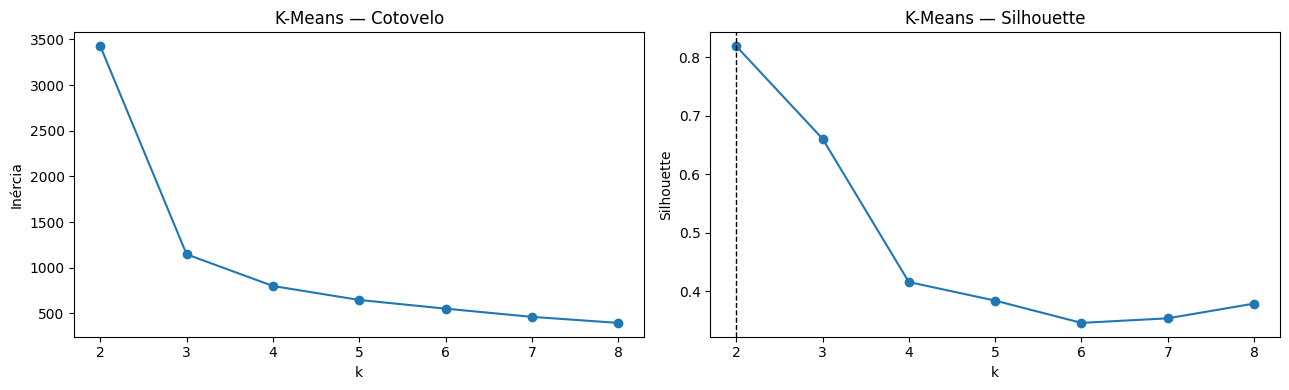

,Cluster_KMeans,Pais
0,0,"[AUT, BEL, BGR, BIH, BRA, CYP, CZE, DEU, DNK, ..."
1,1,"[CRI, HUN, ISL]"


In [5]:
X2d = tensor.reshape(N_PAISES, -1)

K_RANGE = range(2, min(9, N_PAISES))

inertias = []
silhouettes_km = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels = km.fit_predict(X2d)

    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X2d, labels))

df_km_eval = pd.DataFrame({
    "k": list(K_RANGE),
    "Inercia": inertias,
    "Silhouette": silhouettes_km,
})

K_OTIMO_KM = int(df_km_eval.loc[df_km_eval["Silhouette"].idxmax(), "k"])

print(f"K ótimo pelo silhouette: {K_OTIMO_KM}")
display(df_km_eval)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_km_eval["k"], df_km_eval["Inercia"], marker="o")
axes[0].set_title("K-Means — Cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

axes[1].plot(df_km_eval["k"], df_km_eval["Silhouette"], marker="o")
axes[1].axvline(K_OTIMO_KM, linestyle="--", color="black", linewidth=1)
axes[1].set_title("K-Means — Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

km_final = KMeans(n_clusters=K_OTIMO_KM, random_state=RANDOM_STATE, n_init=N_INIT)
labels_km = km_final.fit_predict(X2d)

clusters_km = pd.DataFrame({
    "Pais": PAISES,
    "Cluster_KMeans": labels_km
}).sort_values(["Cluster_KMeans", "Pais"])

display(clusters_km.groupby("Cluster_KMeans")["Pais"].apply(list).reset_index())

---

## 5. Clustering temporal com DTW + agrupamento hierárquico

A etapa anterior usa K-Means sobre vetores achatados. Isso é útil, mas perde parte da intuição temporal da trajetória. Por isso, o notebook também usa DTW, ou *Dynamic Time Warping*.

O DTW é uma técnica para comparar séries temporais. Ele mede a distância entre trajetórias considerando o formato das curvas ao longo do tempo. Isso é interessante quando queremos comparar países que podem seguir padrões parecidos, mesmo que algumas mudanças ocorram em momentos ligeiramente diferentes.

Aqui, o DTW é aplicado apenas sobre:

```text
PROD
TAMANHO_MEDIO
```

Essa decisão é proposital. Esses dois indicadores descrevem a estrutura do mercado: produtividade e tamanho médio das empresas. Assim, o DTW foca menos no tamanho absoluto do país e mais na forma da evolução estrutural.

Depois de calcular a matriz de distâncias DTW entre todos os países, o notebook aplica agrupamento hierárquico com `average-linkage`. Esse método é mais adequado que `ward` quando estamos trabalhando com uma matriz de distâncias pré-computada e não diretamente com coordenadas euclidianas.

A avaliação por silhouette também usa:

```python
metric="precomputed"
```

Isso garante que o silhouette seja calculado com base na própria matriz DTW, e não em uma distância diferente da usada para formar os grupos.


K ótimo DTW + Hierárquico: 2


,k,Silhouette_DTW
0,2,0.849575
1,3,0.764979
2,4,0.689975
3,5,0.633863
4,6,0.603270
5,7,0.346057
6,8,0.327596


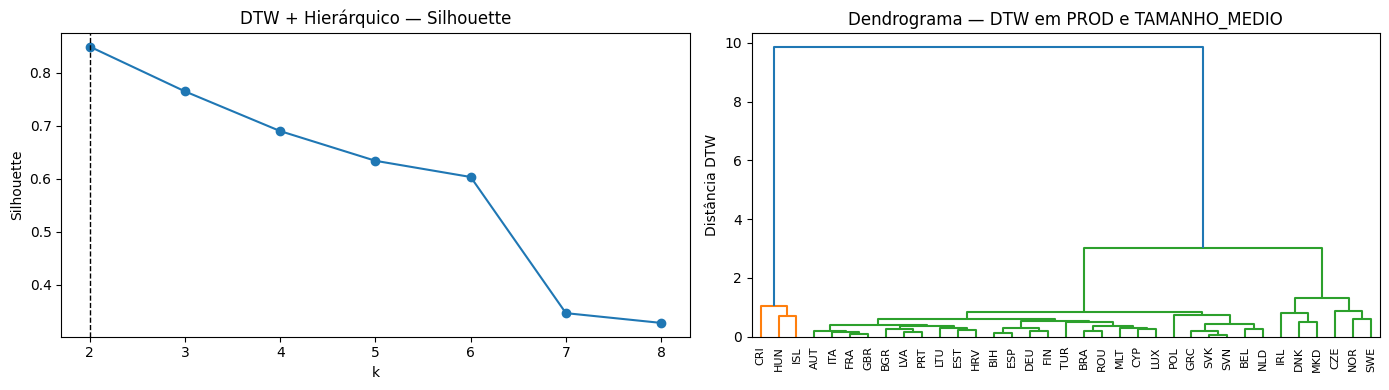

,Cluster_DTW,Pais
0,1,"[CRI, HUN, ISL]"
1,2,"[AUT, BEL, BGR, BIH, BRA, CYP, CZE, DEU, DNK, ..."


In [6]:
def dtw_distance_multivariate(a, b):
    n, m = len(a), len(b)
    matriz = np.full((n + 1, m + 1), np.inf)
    matriz[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            custo = np.linalg.norm(a[i - 1] - b[j - 1])
            matriz[i, j] = custo + min(
                matriz[i - 1, j],
                matriz[i, j - 1],
                matriz[i - 1, j - 1]
            )

    return matriz[n, m] / (n + m)


idx_prod = INDICADORES.index("PROD")
idx_tamanho = INDICADORES.index("TAMANHO_MEDIO")

tensor_dtw = tensor[:, :, [idx_prod, idx_tamanho]]

dist_matrix = np.zeros((N_PAISES, N_PAISES))

for i in range(N_PAISES):
    for j in range(i + 1, N_PAISES):
        d = dtw_distance_multivariate(tensor_dtw[i], tensor_dtw[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d

condensed = squareform(dist_matrix)
Z = linkage(condensed, method="average")

silhouettes_dtw = []

for k in K_RANGE:
    labels_h = fcluster(Z, k, criterion="maxclust")
    sil = silhouette_score(dist_matrix, labels_h, metric="precomputed")
    silhouettes_dtw.append(sil)

df_dtw_eval = pd.DataFrame({
    "k": list(K_RANGE),
    "Silhouette_DTW": silhouettes_dtw,
})

K_OTIMO_DTW = int(df_dtw_eval.loc[df_dtw_eval["Silhouette_DTW"].idxmax(), "k"])

print(f"K ótimo DTW + Hierárquico: {K_OTIMO_DTW}")
display(df_dtw_eval)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_dtw_eval["k"], df_dtw_eval["Silhouette_DTW"], marker="o")
axes[0].axvline(K_OTIMO_DTW, linestyle="--", color="black", linewidth=1)
axes[0].set_title("DTW + Hierárquico — Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

dendrogram(Z, labels=PAISES, ax=axes[1], leaf_rotation=90)
axes[1].set_title("Dendrograma — DTW em PROD e TAMANHO_MEDIO")
axes[1].set_ylabel("Distância DTW")

plt.tight_layout()
plt.show()

labels_dtw = fcluster(Z, K_OTIMO_DTW, criterion="maxclust")

clusters_dtw = pd.DataFrame({
    "Pais": PAISES,
    "Cluster_DTW": labels_dtw
}).sort_values(["Cluster_DTW", "Pais"])

display(clusters_dtw.groupby("Cluster_DTW")["Pais"].apply(list).reset_index())

### 5.1 Comparação entre K-Means e DTW

Esta etapa compara os agrupamentos produzidos pelo K-Means e pelo DTW.

Não seria correto comparar diretamente os números dos clusters, porque os rótulos são arbitrários. Por exemplo, o cluster `0` do K-Means não necessariamente corresponde ao cluster `0` do DTW.

Por isso, o notebook usa duas métricas formais:

- **Adjusted Rand Index (ARI)**: mede a concordância entre duas clusterizações, corrigindo o acaso.
- **Normalized Mutual Information (NMI)**: mede quanto de informação uma clusterização compartilha com a outra.

A interpretação deve ser cuidadosa. Uma concordância baixa ou moderada não significa necessariamente que um método está errado. Pode significar que os métodos capturam aspectos diferentes dos dados. O K-Means usa todos os indicadores e mistura escala com estrutura. O DTW foca a trajetória estrutural de produtividade e tamanho médio.


In [7]:
ari = adjusted_rand_score(labels_km, labels_dtw)
nmi = normalized_mutual_info_score(labels_km, labels_dtw)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

Adjusted Rand Index: 1.000
Normalized Mutual Information: 1.000


---

## 6. Estágios de maturidade — versão aprimorada

Esta seção tenta transformar os indicadores estruturais em uma classificação interpretável de maturidade do mercado.

A maturidade é calculada a partir de:

```text
PROD
TAMANHO_MEDIO
```

A lógica econômica é a seguinte: mercados com maior produtividade e maior estrutura média das empresas podem indicar um setor mais consolidado ou mais denso em capacidade produtiva. Mercados com produtividade menor e empresas muito pequenas podem indicar um setor mais fragmentado ou em estágio mais inicial.

Contudo, existe um cuidado importante. Países com produtividade muito atípica não devem ser automaticamente tratados como “mais maduros”. Uma produtividade extremamente alta pode refletir eficiência real, mas também pode decorrer de efeito de país pequeno, composição setorial, diferenças metodológicas ou problemas de escala. Por isso, os outliers de produtividade são separados em um grupo próprio.

Esta versão corrige uma limitação anterior: quando a maturidade era calculada com escala global simples, muitos países ficavam comprimidos no mesmo estágio. Agora, a etapa usa:

```text
log1p + RobustScaler
```

além de ajustar a escala apenas com países não outliers. A classificação principal usa três estágios interpretáveis entre os países não outliers e adiciona um grupo separado para perfis atípicos de produtividade.

O notebook ainda mostra a tabela de silhouette como diagnóstico. Mesmo que o silhouette sugira menos grupos, o uso de três estágios pode ser preferível para análise exploratória, pois permite distinguir melhor níveis relativos de maturidade entre países não extremos.


In [8]:
medias_pais = (
    df.groupby("Pais", as_index=False)
    .agg(
        PROD=("PROD", "mean"),
        TAMANHO_MEDIO=("TAMANHO_MEDIO", "mean"),
        Flag_Outlier_Prod=("Flag_Outlier_Prod", "max")
    )
)

base_est = medias_pais[medias_pais["Flag_Outlier_Prod"].eq(0)].copy()

X_est_log = np.log1p(base_est[INDICADORES_ESTRUTURAIS].astype(float))
scaler_est = RobustScaler()
X_est = scaler_est.fit_transform(X_est_log)

K_RANGE_EST = range(2, min(7, len(base_est)))
silhouettes_est = []

for k in K_RANGE_EST:
    km_est_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_tmp = km_est_tmp.fit_predict(X_est)
    silhouettes_est.append(silhouette_score(X_est, labels_tmp))

df_est_eval = pd.DataFrame({
    "k": list(K_RANGE_EST),
    "Silhouette": silhouettes_est
})

K_ESTAGIO_SILHOUETTE = int(df_est_eval.loc[df_est_eval["Silhouette"].idxmax(), "k"])
K_ESTAGIO_BASE = 3

print(f"K sugerido pelo silhouette: {K_ESTAGIO_SILHOUETTE}")
print(f"K usado para estágios interpretáveis entre não outliers: {K_ESTAGIO_BASE}")
display(df_est_eval)

km_estagio = KMeans(n_clusters=K_ESTAGIO_BASE, random_state=RANDOM_STATE, n_init=N_INIT)
base_est["Estagio_Raw"] = km_estagio.fit_predict(X_est)

base_est[["PROD_log_robust", "TAMANHO_log_robust"]] = X_est
base_est["Score_Maturidade"] = base_est["PROD_log_robust"] + base_est["TAMANHO_log_robust"]

ordem_estagios = (
    base_est.groupby("Estagio_Raw")["Score_Maturidade"]
    .mean()
    .sort_values()
    .index
)

mapa_estagio = {raw: i + 1 for i, raw in enumerate(ordem_estagios)}
base_est["Estagio"] = base_est["Estagio_Raw"].map(mapa_estagio)

medias_pais = medias_pais.merge(
    base_est[["Pais", "Estagio"]],
    on="Pais",
    how="left"
)

ESTAGIO_OUTLIER = K_ESTAGIO_BASE + 1
medias_pais.loc[
    medias_pais["Flag_Outlier_Prod"].eq(1),
    "Estagio"
] = ESTAGIO_OUTLIER

X_all_est = scaler_est.transform(np.log1p(medias_pais[INDICADORES_ESTRUTURAIS].astype(float)))
medias_pais["PROD_log_robust"] = X_all_est[:, 0]
medias_pais["TAMANHO_log_robust"] = X_all_est[:, 1]
medias_pais["Score_Maturidade"] = medias_pais["PROD_log_robust"] + medias_pais["TAMANHO_log_robust"]
medias_pais["Estagio"] = medias_pais["Estagio"].astype(int)

nomes_estagio = {
    1: "Estágio 1 — menor estrutura/produtividade relativa",
    2: "Estágio 2 — perfil intermediário",
    3: "Estágio 3 — maior estrutura/produtividade relativa",
    ESTAGIO_OUTLIER: "Perfil atípico de produtividade aparente"
}

display(
    medias_pais
    .sort_values(["Estagio", "Score_Maturidade", "Pais"])
    .reset_index(drop=True)
)

display(
    medias_pais.groupby("Estagio")["Pais"]
    .apply(list)
    .reset_index()
)

K sugerido pelo silhouette: 2
K usado para estágios interpretáveis entre não outliers: 3


,k,Silhouette
0,2,0.736111
1,3,0.437215
2,4,0.410013
3,5,0.431862
4,6,0.369939


,Pais,PROD,TAMANHO_MEDIO,Flag_Outlier_Prod,Estagio,PROD_log_robust,TAMANHO_log_robust,Score_Maturidade
0,SVN,0.121164,1.904379,0,1,-0.350903,-1.742073,-2.092976
1,GRC,0.093370,2.151311,0,1,-0.510626,-1.531433,-2.042059
2,SVK,0.112248,2.153429,0,1,-0.401707,-1.529698,-1.931405
3,EST,0.089000,3.104010,0,1,-0.536109,-0.849561,-1.385671
4,HRV,0.069426,3.512877,0,1,-0.651517,-0.604403,-1.255920
5,NLD,0.213164,2.729340,0,1,0.150891,-1.096689,-0.945797
6,BEL,0.291985,2.280345,0,1,0.551414,-1.427840,-0.876427
7,ITA,0.153189,3.789120,0,1,-0.171704,-0.451037,-0.622741
8,POL,0.448347,1.913588,0,1,1.278316,-1.733901,-0.455585
9,AUT,0.207375,3.708482,0,1,0.120455,-0.494872,-0.374417


,Estagio,Pais
0,1,"[AUT, BEL, EST, GRC, HRV, ITA, NLD, POL, SVK, ..."
1,2,"[BGR, BIH, BRA, CYP, DEU, ESP, FIN, FRA, GBR, ..."
2,3,"[DNK, IRL, MKD, NOR]"
3,4,"[CRI, CZE, HUN, ISL, SWE]"


### 6.1 Mapa de maturidade em escala robusta

O mapa de maturidade mostra cada país no espaço formado por produtividade e tamanho médio das empresas, já transformados por `log1p + RobustScaler`.

Esse gráfico ajuda a visualizar onde os países se posicionam em termos de estrutura do mercado. Países mais à direita têm maior tamanho médio relativo das empresas. Países mais acima têm maior produtividade relativa. Os grupos coloridos representam os estágios definidos pelo modelo.

A escala robusta é essencial aqui. Sem ela, países com valores extremos fariam a maioria dos demais aparecer muito próxima visualmente, dificultando a interpretação.

A leitura correta do gráfico não é “um estágio é necessariamente melhor que o outro”. A leitura mais adequada é:

```text
os estágios representam perfis estruturais relativos dentro da amostra analisada
```

O grupo de perfis atípicos deve ser interpretado com cuidado, não como uma categoria automática de superioridade.


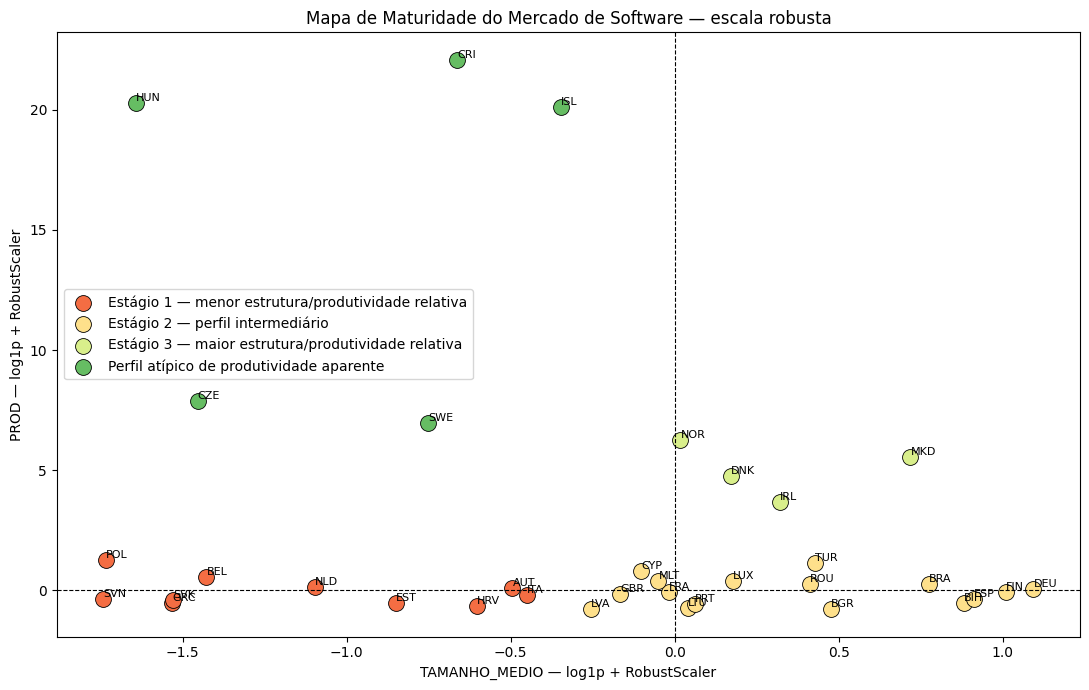

In [9]:
estagios_unicos = sorted(medias_pais["Estagio"].unique())
cores_estagio = dict(zip(estagios_unicos, sns.color_palette("RdYlGn", len(estagios_unicos))))

fig, ax = plt.subplots(figsize=(11, 7))

for est in estagios_unicos:
    grupo = medias_pais[medias_pais["Estagio"].eq(est)]

    ax.scatter(
        grupo["TAMANHO_log_robust"],
        grupo["PROD_log_robust"],
        s=130,
        color=cores_estagio[est],
        edgecolor="black",
        linewidth=0.6,
        label=nomes_estagio.get(est, f"Estágio {est}")
    )

    for _, row in grupo.iterrows():
        ax.text(
            row["TAMANHO_log_robust"],
            row["PROD_log_robust"],
            row["Pais"],
            fontsize=8,
            ha="left",
            va="bottom"
        )

ax.axhline(0, linestyle="--", color="black", linewidth=0.8)
ax.axvline(0, linestyle="--", color="black", linewidth=0.8)
ax.set_xlabel("TAMANHO_MEDIO — log1p + RobustScaler")
ax.set_ylabel("PROD — log1p + RobustScaler")
ax.set_title("Mapa de Maturidade do Mercado de Software — escala robusta")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 6.2 Evolução de maturidade por janelas

Aqui o notebook divide o período em janelas temporais:

```text
2010–2012
2013–2015
2016–2018
2019–2022
```

Para cada país e para cada janela, ele calcula um estágio de maturidade e um score contínuo.

O estágio discreto permite ver mudanças de categoria ao longo do tempo. Já o score contínuo permite enxergar movimentos mais sutis. Isso é importante porque um país pode permanecer no mesmo estágio, mas ainda assim melhorar ou piorar internamente.

A coluna `Delta_Score` resume a variação do score de maturidade entre a primeira e a última janela observada. Valores positivos indicam avanço relativo no espaço estrutural usado pelo modelo. Valores negativos indicam recuo relativo.

Essa etapa transforma a análise de maturidade em uma análise temporal. Em vez de perguntar apenas “em qual estágio o país está?”, o notebook passa a perguntar:

> Como o perfil estrutural do país mudou ao longo do tempo?


In [10]:
def classificar_estagio_por_janela(pais, j_ini, j_fim):
    sub = df[(df["Pais"].eq(pais)) & (df["Ano"].between(j_ini, j_fim))]
    if len(sub) == 0:
        return None

    prod_media = sub["PROD"].mean()
    tamanho_media = sub["TAMANHO_MEDIO"].mean()
    flag_outlier = int(sub["Flag_Outlier_Prod"].max())

    x = scaler_est.transform(np.log1p(pd.DataFrame({
        "PROD": [prod_media],
        "TAMANHO_MEDIO": [tamanho_media]
    })))
    score = float(x[0, 0] + x[0, 1])

    if flag_outlier == 1:
        estagio = ESTAGIO_OUTLIER
    else:
        raw = int(km_estagio.predict(x)[0])
        estagio = int(mapa_estagio[raw])

    return {
        "Pais": pais,
        "Janela": f"{j_ini}-{j_fim}",
        "Estagio": estagio,
        "Score_Maturidade": score,
        "PROD_media": prod_media,
        "TAMANHO_MEDIO_medio": tamanho_media,
    }


linhas_evolucao = []

for pais in PAISES:
    for j_ini, j_fim, _ in JANELAS_TWIN:
        item = classificar_estagio_por_janela(pais, j_ini, j_fim)
        if item is not None:
            linhas_evolucao.append(item)

df_evolucao = pd.DataFrame(linhas_evolucao)

pivot_estagio = df_evolucao.pivot(index="Pais", columns="Janela", values="Estagio")
pivot_score = df_evolucao.pivot(index="Pais", columns="Janela", values="Score_Maturidade")

print("Estágio por país e janela:")
display(pivot_estagio)

print("Score contínuo de maturidade por país e janela:")
display(pivot_score.round(3))

resumo_mov = []
for pais, grupo in df_evolucao.groupby("Pais"):
    grupo = grupo.sort_values("Janela")
    resumo_mov.append({
        "Pais": pais,
        "Estagio_Inicial": int(grupo["Estagio"].iloc[0]),
        "Estagio_Final": int(grupo["Estagio"].iloc[-1]),
        "Delta_Score": float(grupo["Score_Maturidade"].iloc[-1] - grupo["Score_Maturidade"].iloc[0])
    })

resumo_mov = pd.DataFrame(resumo_mov)
print("\nResumo da evolução:")
display(resumo_mov.sort_values("Delta_Score", ascending=False).reset_index(drop=True))

Estágio por país e janela:


Janela,2010-2012,2013-2015,2016-2018,2019-2022
Pais,,,,
AUT,1.0,1.0,2.0,1.0
BEL,1.0,1.0,1.0,1.0
BGR,2.0,2.0,2.0,2.0
BIH,2.0,2.0,2.0,2.0
BRA,2.0,2.0,2.0,2.0
CRI,4.0,4.0,4.0,4.0
CYP,2.0,2.0,2.0,2.0
CZE,4.0,4.0,4.0,4.0
DEU,2.0,2.0,2.0,2.0


Score contínuo de maturidade por país e janela:


Janela,2010-2012,2013-2015,2016-2018,2019-2022
Pais,,,,
AUT,-0.647,-0.400,-0.186,-0.304
BEL,-0.835,-0.976,-0.906,-0.819
BGR,-0.584,-0.515,-0.334,0.081
BIH,0.486,0.333,0.270,0.393
BRA,0.388,0.850,1.257,1.616
CRI,20.272,20.623,21.692,22.469
CYP,0.752,0.636,0.499,0.767
CZE,6.068,6.037,6.288,7.035
DEU,0.933,0.956,1.062,1.482



Resumo da evolução:


,Pais,Estagio_Inicial,Estagio_Final,Delta_Score
0,SWE,4,4,3.602649
1,HUN,4,4,2.765360
2,ISL,4,4,2.734984
3,TUR,2,3,2.295612
4,CRI,4,4,2.196674
5,MLT,1,2,1.700825
6,NOR,3,3,1.444250
7,IRL,3,3,1.423426
8,BRA,2,2,1.227528
9,CZE,4,4,0.967445


---

## 7. Market Twin amplo e estrutural

Esta é a seção central do notebook.

A ideia de **Market Twin** é encontrar países que, em janelas anteriores, eram parecidos com o país de referência na janela mais recente. No caso deste notebook, o país de referência é a Polônia (`POL`) e a janela recente é 2019–2022.

A pergunta principal é:

> Quais países, no passado, tinham um mercado de software parecido com a Polônia recente?

O notebook calcula uma “assinatura” média do país em uma janela temporal. Essa assinatura é simplesmente o vetor médio dos indicadores escolhidos naquele período. Depois, compara essa assinatura da Polônia recente com assinaturas de outros países em janelas anteriores.

Existem duas versões de Market Twin:

### Market Twin amplo

Usa os cinco indicadores:

```text
ENTR
TUTT
EMPE
PROD
TAMANHO_MEDIO
```

Essa versão compara escala e estrutura ao mesmo tempo. Ela responde: quais países eram parecidos com a Polônia considerando tamanho do mercado, emprego, valor econômico, produtividade e tamanho médio das empresas?

### Market Twin estrutural

Usa apenas:

```text
PROD
TAMANHO_MEDIO
```

Essa versão ignora o tamanho absoluto do mercado e foca apenas a estrutura produtiva. Ela responde: quais países tinham produtividade e tamanho médio de empresas parecidos com a Polônia recente?

A diferença entre as duas versões é uma das partes mais importantes da análise. Ela mostra que “ser parecido” depende da definição de similaridade.


In [11]:
def get_assinatura(dados, pais, j_ini, j_fim, indicadores, min_obs=2):
    mask = (dados["Pais"].eq(pais)) & (dados["Ano"].between(j_ini, j_fim))
    sub = dados.loc[mask, indicadores]

    if len(sub) < min_obs:
        return None

    if sub.isna().any().any():
        return None

    return sub.mean().values


def obter_estagio_pais(pais):
    linha = medias_pais.loc[medias_pais["Pais"].eq(pais)]
    if linha.empty:
        return np.nan
    return int(linha["Estagio"].iloc[0])


def calcular_market_twins(
    pais_referencia,
    indicadores,
    janela_ref=(2019, 2022),
    janelas_comparacao=None,
    excluir_proprio=True,
    top_n=10
):
    if janelas_comparacao is None:
        janelas_comparacao = JANELAS_TWIN[:-1]

    sig_ref = get_assinatura(
        df_model,
        pais_referencia,
        janela_ref[0],
        janela_ref[1],
        indicadores
    )

    if sig_ref is None:
        raise ValueError(f"Não foi possível calcular assinatura de referência para {pais_referencia}.")

    linhas = []

    for pais in PAISES:
        if excluir_proprio and pais == pais_referencia:
            continue

        for j_ini, j_fim, rotulo in janelas_comparacao:
            sig = get_assinatura(df_model, pais, j_ini, j_fim, indicadores)

            if sig is None:
                continue

            distancia = float(np.linalg.norm(sig_ref - sig))

            linhas.append({
                "Pais_Referencia": pais_referencia,
                "Janela_Referencia": f"{janela_ref[0]}-{janela_ref[1]}",
                "Twin": pais,
                "Janela_Twin": rotulo,
                "Ano_Inicio_Twin": j_ini,
                "Ano_Fim_Twin": j_fim,
                "Distancia": distancia,
                "Estagio_Twin": obter_estagio_pais(pais)
            })

    resultado = (
        pd.DataFrame(linhas)
        .sort_values("Distancia")
        .reset_index(drop=True)
    )

    return resultado.head(top_n), resultado


top_twins_amplo, todos_twins_amplo = calcular_market_twins(
    PAIS_REFERENCIA,
    INDICADORES,
    janela_ref=JANELA_REFERENCIA,
    top_n=10
)

top_twins_estrutural, todos_twins_estrutural = calcular_market_twins(
    PAIS_REFERENCIA,
    INDICADORES_ESTRUTURAIS,
    janela_ref=JANELA_REFERENCIA,
    top_n=10
)

print(f"País de referência: {PAIS_REFERENCIA}")

print("\nTop Market Twins — definição ampla:")
display(top_twins_amplo)

print("\nTop Market Twins — definição estrutural:")
display(top_twins_estrutural)

País de referência: POL

Top Market Twins — definição ampla:


,Pais_Referencia,Janela_Referencia,Twin,Janela_Twin,Ano_Inicio_Twin,Ano_Fim_Twin,Distancia,Estagio_Twin
0,POL,2019-2022,BEL,2016-2018,2016,2018,1.707373,1
1,POL,2019-2022,NLD,2016-2018,2016,2018,1.730729,1
2,POL,2019-2022,BEL,2013-2015,2013,2015,1.842391,1
3,POL,2019-2022,NLD,2013-2015,2013,2015,1.939022,1
4,POL,2019-2022,BEL,2010-2012,2010,2012,1.986087,1
5,POL,2019-2022,NLD,2010-2012,2010,2012,2.271726,1
6,POL,2019-2022,ITA,2010-2012,2010,2012,2.327558,1
7,POL,2019-2022,ITA,2013-2015,2013,2015,2.382170,1
8,POL,2019-2022,ITA,2016-2018,2016,2018,2.425298,1
9,POL,2019-2022,FRA,2013-2015,2013,2015,2.478376,2



Top Market Twins — definição estrutural:


,Pais_Referencia,Janela_Referencia,Twin,Janela_Twin,Ano_Inicio_Twin,Ano_Fim_Twin,Distancia,Estagio_Twin
0,POL,2019-2022,BEL,2016-2018,2016,2018,1.292625,1
1,POL,2019-2022,BEL,2013-2015,2013,2015,1.370518,1
2,POL,2019-2022,BEL,2010-2012,2010,2012,1.490368,1
3,POL,2019-2022,NLD,2016-2018,2016,2018,1.675612,1
4,POL,2019-2022,CYP,2016-2018,2016,2018,1.698103,2
5,POL,2019-2022,MLT,2010-2012,2010,2012,1.806688,2
6,POL,2019-2022,NLD,2013-2015,2013,2015,1.853498,1
7,POL,2019-2022,AUT,2010-2012,2010,2012,2.119245,1
8,POL,2019-2022,AUT,2013-2015,2013,2015,2.138363,1
9,POL,2019-2022,SVN,2016-2018,2016,2018,2.141983,1


### 7.1 Comparação visual dos twins

As tabelas de Market Twin mostram as menores distâncias numéricas, mas os gráficos ajudam a interpretar visualmente os resultados.

O gráfico apresenta a trajetória completa do indicador escolhido, geralmente `PROD`, para a Polônia e para os países identificados como twins. A janela recente da Polônia e as janelas históricas dos twins são destacadas visualmente.

É importante entender uma nuance: a distância do Market Twin é calculada usando uma janela específica, mas o gráfico mostra a trajetória completa para contextualização. Isso permite observar se a semelhança é pontual, persistente ou parte de uma tendência maior.

Essa etapa é especialmente útil para apresentação ao grupo, porque transforma os resultados de distância em uma leitura visual mais intuitiva.


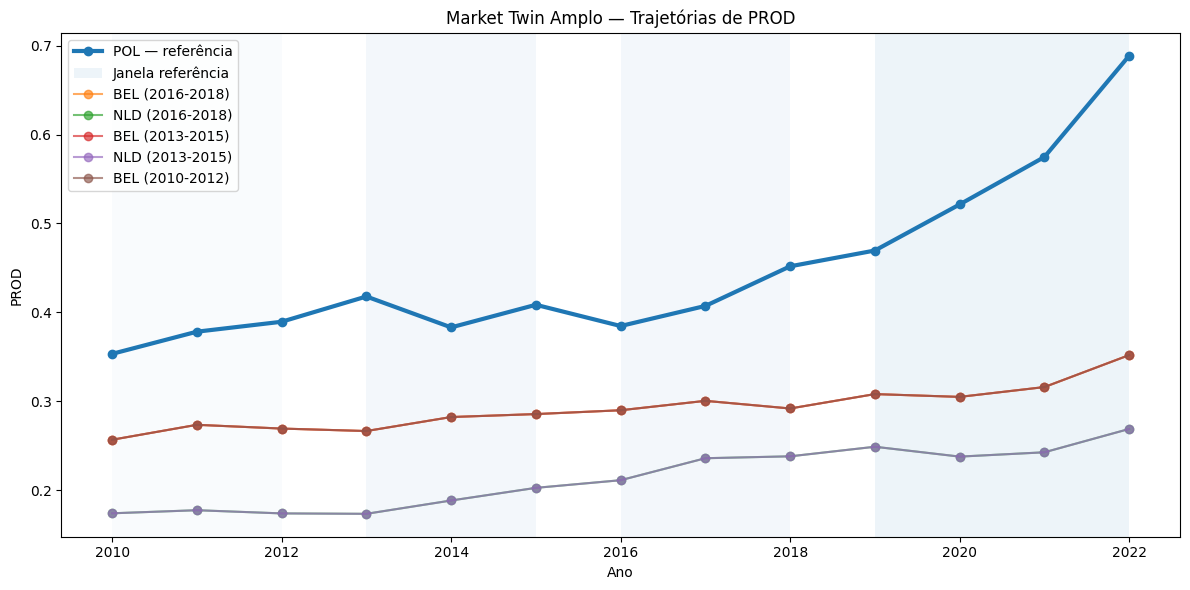

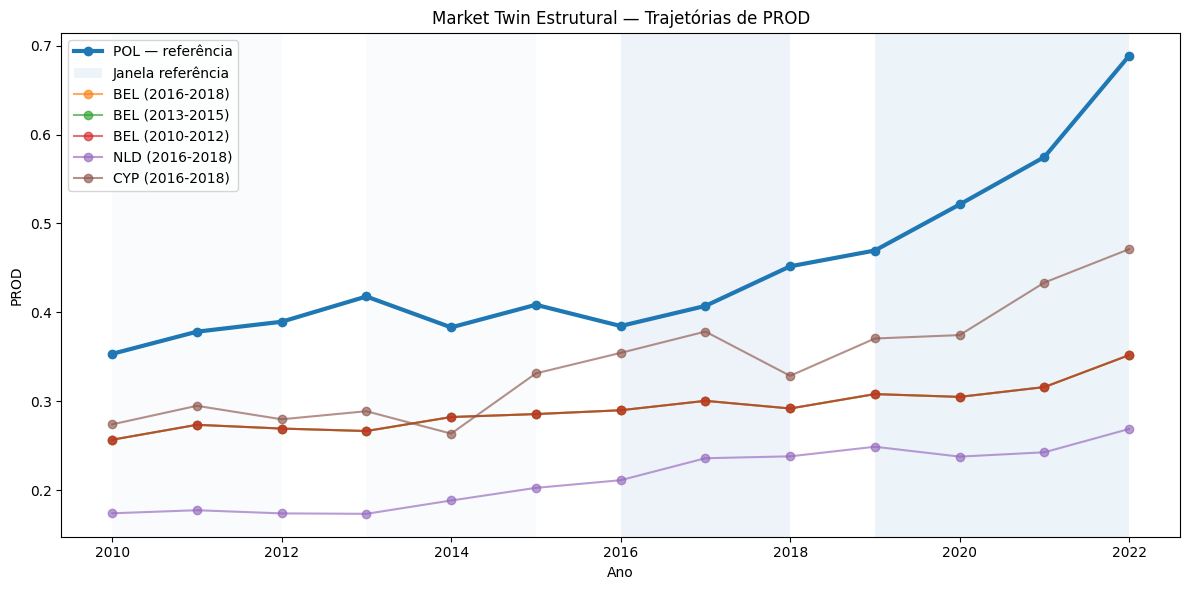

In [12]:
def plotar_trajetoria_twins(pais_ref, tabela_twins, titulo, indicador="PROD", n=5):
    fig, ax = plt.subplots(figsize=(12, 6))

    dp_ref = df[df["Pais"].eq(pais_ref)].sort_values("Ano")
    ax.plot(
        dp_ref["Ano"],
        dp_ref[indicador],
        marker="o",
        linewidth=3,
        label=f"{pais_ref} — referência"
    )

    ax.axvspan(JANELA_REFERENCIA[0], JANELA_REFERENCIA[1], alpha=0.08, label="Janela referência")

    for _, row in tabela_twins.head(n).iterrows():
        twin = row["Twin"]
        dp_twin = df[df["Pais"].eq(twin)].sort_values("Ano")

        ax.plot(
            dp_twin["Ano"],
            dp_twin[indicador],
            marker="o",
            alpha=0.65,
            label=f"{twin} ({row['Janela_Twin']})"
        )
        ax.axvspan(row["Ano_Inicio_Twin"], row["Ano_Fim_Twin"], alpha=0.025)

    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel(indicador)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


plotar_trajetoria_twins(
    PAIS_REFERENCIA,
    top_twins_amplo,
    "Market Twin Amplo — Trajetórias de PROD",
    indicador="PROD",
    n=5
)

plotar_trajetoria_twins(
    PAIS_REFERENCIA,
    top_twins_estrutural,
    "Market Twin Estrutural — Trajetórias de PROD",
    indicador="PROD",
    n=5
)

### 7.2 Narrativa automática para o país de referência

Esta célula produz uma síntese textual automática dos principais resultados para a Polônia.

Ela resume três informações importantes:

1. qual foi o twin mais próximo no Market Twin amplo;
2. qual foi o twin mais próximo no Market Twin estrutural;
3. como a trajetória da Polônia mudou em `ENTR`, `PROD` e `TAMANHO_MEDIO`.

Essa narrativa serve como uma ponte entre o resultado técnico e a interpretação econômica. Ela ajuda a transformar tabelas e gráficos em uma explicação que pode ser usada em relatório ou apresentação.

Mesmo assim, a interpretação final deve ser feita com cuidado. O twin mais próximo não é uma previsão automática do futuro da Polônia. Ele é uma referência histórica de similaridade dentro dos dados disponíveis.


In [13]:
twin_amplo = top_twins_amplo.iloc[0]
twin_estrutural = top_twins_estrutural.iloc[0]

dp_ref = df[df["Pais"].eq(PAIS_REFERENCIA)].sort_values("Ano")

resumo_ref = {
    "ENTR_inicial": dp_ref["ENTR"].iloc[0],
    "ENTR_final": dp_ref["ENTR"].iloc[-1],
    "PROD_inicial": dp_ref["PROD"].iloc[0],
    "PROD_final": dp_ref["PROD"].iloc[-1],
    "TAMANHO_inicial": dp_ref["TAMANHO_MEDIO"].iloc[0],
    "TAMANHO_final": dp_ref["TAMANHO_MEDIO"].iloc[-1],
}

print(f"Análise automática — {PAIS_REFERENCIA}")
print()
print(
    f"No Market Twin amplo, que considera escala e estrutura simultaneamente, "
    f"o par mais próximo de {PAIS_REFERENCIA} é {twin_amplo['Twin']} "
    f"na janela {twin_amplo['Janela_Twin']}, com distância {twin_amplo['Distancia']:.3f}."
)
print(
    f"No Market Twin estrutural, que usa apenas produtividade e tamanho médio das empresas, "
    f"o par mais próximo é {twin_estrutural['Twin']} na janela {twin_estrutural['Janela_Twin']}, "
    f"com distância {twin_estrutural['Distancia']:.3f}."
)
print()
print(
    f"A trajetória de {PAIS_REFERENCIA} mostra ENTR de {resumo_ref['ENTR_inicial']:.1f} "
    f"para {resumo_ref['ENTR_final']:.1f}, PROD de {resumo_ref['PROD_inicial']:.4f} "
    f"para {resumo_ref['PROD_final']:.4f}, e TAMANHO_MEDIO de "
    f"{resumo_ref['TAMANHO_inicial']:.4f} para {resumo_ref['TAMANHO_final']:.4f}."
)

Análise automática — POL

No Market Twin amplo, que considera escala e estrutura simultaneamente, o par mais próximo de POL é BEL na janela 2016-2018, com distância 1.707.
No Market Twin estrutural, que usa apenas produtividade e tamanho médio das empresas, o par mais próximo é BEL na janela 2016-2018, com distância 1.293.

A trajetória de POL mostra ENTR de 37527.0 para 166695.0, PROD de 0.3533 para 0.6888, e TAMANHO_MEDIO de 2.0438 para 1.4852.


---

## 8. Convergência e divergência com CAGR

Depois da análise de similaridade, o notebook avalia a dinâmica de crescimento dos países.

Para isso, usa CAGR, que significa taxa composta de crescimento anual. Essa métrica mostra o crescimento médio anual entre o primeiro e o último ano disponível de cada país.

O uso de CAGR é melhor do que crescimento acumulado simples porque alguns países podem ter séries com comprimentos ligeiramente diferentes. Com CAGR, a comparação fica mais justa, pois o crescimento é anualizado.

A análise calcula CAGR para:

```text
PROD
ENTR
TAMANHO_MEDIO
```

Depois, os países são classificados em quadrantes usando como referência as medianas de crescimento de produtividade e de número de empresas.

A leitura dos quadrantes é:

- **Acelerou**: crescimento de produtividade acima da mediana e crescimento de empresas acima da mediana;
- **Ganhou produtividade com menor expansão**: produtividade cresce relativamente bem, mas número de empresas cresce menos;
- **Expansão com baixa produtividade**: número de empresas cresce, mas produtividade não acompanha no mesmo ritmo;
- **Crescimento baixo/estacionado**: ambos crescem abaixo da mediana.

Essa etapa usa a base preparada em valores reais, e não a escala robusta, porque crescimento econômico deve ser interpretado na unidade original dos indicadores.


In [14]:
def calcular_cagr_pais(dados, pais, col):
    dp = dados[dados["Pais"].eq(pais)].sort_values("Ano")
    dp = dp[["Ano", col]].dropna()

    if len(dp) < 2:
        return np.nan

    ano_ini = int(dp["Ano"].iloc[0])
    ano_fim = int(dp["Ano"].iloc[-1])
    n_anos = ano_fim - ano_ini

    v_ini = float(dp[col].iloc[0])
    v_fim = float(dp[col].iloc[-1])

    if n_anos <= 0 or v_ini <= 0 or v_fim <= 0:
        return np.nan

    return ((v_fim / v_ini) ** (1 / n_anos) - 1) * 100


linhas_conv = []

for pais in PAISES:
    dp = df[df["Pais"].eq(pais)].sort_values("Ano")

    linhas_conv.append({
        "Pais": pais,
        "Ano_Inicial": int(dp["Ano"].min()),
        "Ano_Final": int(dp["Ano"].max()),
        "CAGR_PROD": calcular_cagr_pais(df, pais, "PROD"),
        "CAGR_ENTR": calcular_cagr_pais(df, pais, "ENTR"),
        "CAGR_TAMANHO_MEDIO": calcular_cagr_pais(df, pais, "TAMANHO_MEDIO"),
        "Estagio": obter_estagio_pais(pais)
    })

df_conv = pd.DataFrame(linhas_conv).dropna().reset_index(drop=True)

lim_prod = df_conv["CAGR_PROD"].median()
lim_entr = df_conv["CAGR_ENTR"].median()


def classificar_quadrante(row):
    prod_alta = row["CAGR_PROD"] >= lim_prod
    entr_alta = row["CAGR_ENTR"] >= lim_entr

    if prod_alta and entr_alta:
        return "Acelerou"
    if prod_alta and not entr_alta:
        return "Ganhou produtividade com menor expansão"
    if not prod_alta and entr_alta:
        return "Expansão com baixa produtividade"
    return "Crescimento baixo/estacionado"


df_conv["Quadrante"] = df_conv.apply(classificar_quadrante, axis=1)

display(
    df_conv.sort_values(["Quadrante", "CAGR_PROD"], ascending=[True, False])
    .reset_index(drop=True)
)

,Pais,Ano_Inicial,Ano_Final,CAGR_PROD,CAGR_ENTR,CAGR_TAMANHO_MEDIO,Estagio,Quadrante
0,TUR,2010,2022,21.500662,12.660553,-2.734348,2,Acelerou
1,EST,2010,2022,10.696660,15.573220,-4.180581,1,Acelerou
2,LTU,2010,2022,8.158209,18.659205,-6.163807,2,Acelerou
3,BGR,2010,2022,6.857299,8.158395,2.383625,2,Acelerou
4,BIH,2011,2022,6.441406,38.782827,-2.237739,2,Acelerou
5,POL,2010,2022,5.722019,13.230883,-2.625471,1,Acelerou
6,ROU,2010,2022,5.241830,14.345629,-2.765404,2,Acelerou
7,CYP,2010,2022,4.622972,17.749876,-2.329213,2,Acelerou
8,SVK,2010,2022,4.250711,10.978059,-3.588353,1,Acelerou
9,LVA,2010,2022,3.861770,9.745587,1.713144,2,Acelerou


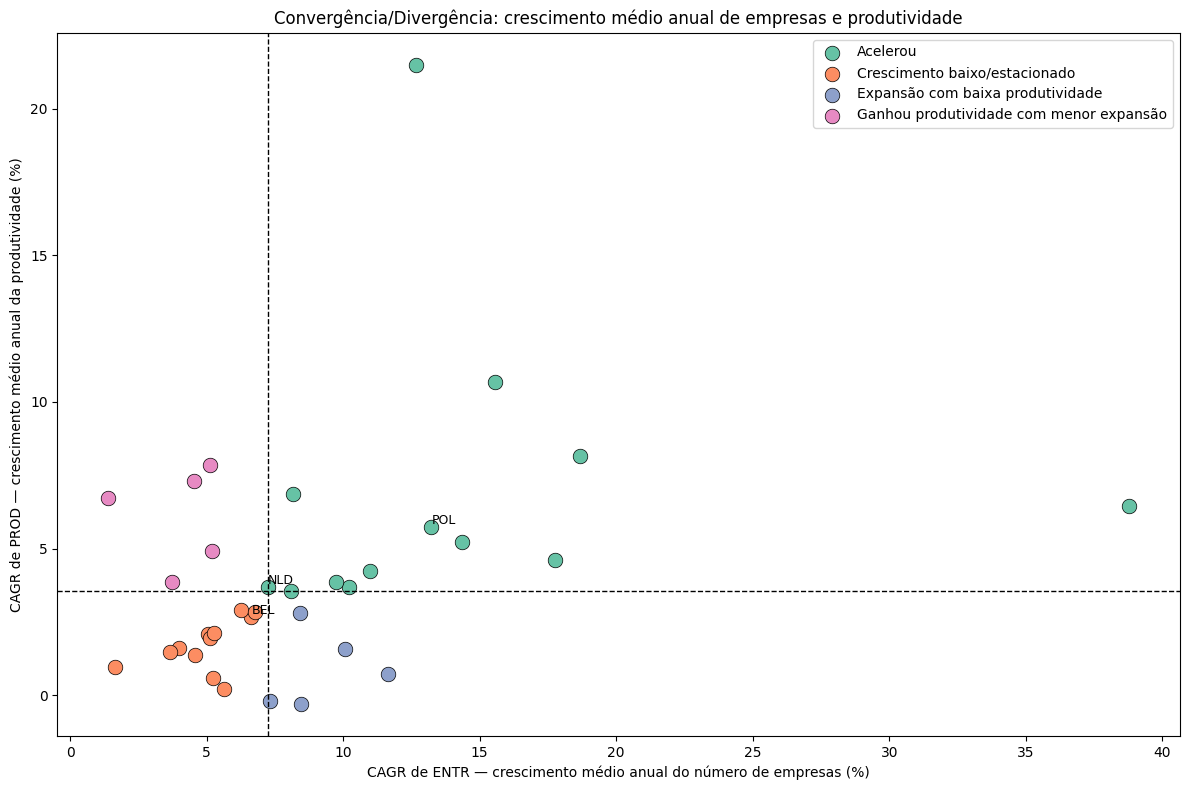

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

quadrantes = sorted(df_conv["Quadrante"].unique())
cores_quad = dict(zip(quadrantes, sns.color_palette("Set2", len(quadrantes))))

for quad, grupo in df_conv.groupby("Quadrante"):
    ax.scatter(
        grupo["CAGR_ENTR"],
        grupo["CAGR_PROD"],
        s=110,
        color=cores_quad[quad],
        edgecolor="black",
        linewidth=0.5,
        label=quad
    )

    for _, row in grupo.iterrows():
        if row["Pais"] == PAIS_REFERENCIA or row["Pais"] in top_twins_amplo["Twin"].head(5).tolist():
            ax.text(
                row["CAGR_ENTR"],
                row["CAGR_PROD"],
                row["Pais"],
                fontsize=9,
                ha="left",
                va="bottom"
            )

ax.axhline(lim_prod, color="black", linestyle="--", linewidth=1)
ax.axvline(lim_entr, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("CAGR de ENTR — crescimento médio anual do número de empresas (%)")
ax.set_ylabel("CAGR de PROD — crescimento médio anual da produtividade (%)")
ax.set_title("Convergência/Divergência: crescimento médio anual de empresas e produtividade")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 8.1 Estrutura empresarial: produtividade × tamanho médio

Este segundo gráfico complementa a análise de convergência.

O gráfico anterior compara crescimento de produtividade com crescimento do número de empresas. Isso ajuda a identificar expansão do mercado. Porém, expansão no número de empresas não diz sozinha se o setor está ficando mais consolidado ou mais fragmentado.

Por isso, este gráfico compara:

```text
CAGR de PROD
CAGR de TAMANHO_MEDIO
```

A interpretação fica mais estrutural:

- se produtividade cresce e tamanho médio também cresce, pode haver consolidação produtiva;
- se produtividade cresce, mas tamanho médio cai, pode haver crescimento com fragmentação;
- se produtividade cresce pouco e tamanho médio cai, pode haver expansão menos robusta;
- se ambos caem, pode haver perda de densidade produtiva.

No caso da Polônia, essa análise é importante porque o país apresenta crescimento de produtividade e forte crescimento no número de empresas, mas redução no tamanho médio das firmas. Isso sugere uma expansão dinâmica, porém com maior fragmentação empresarial.


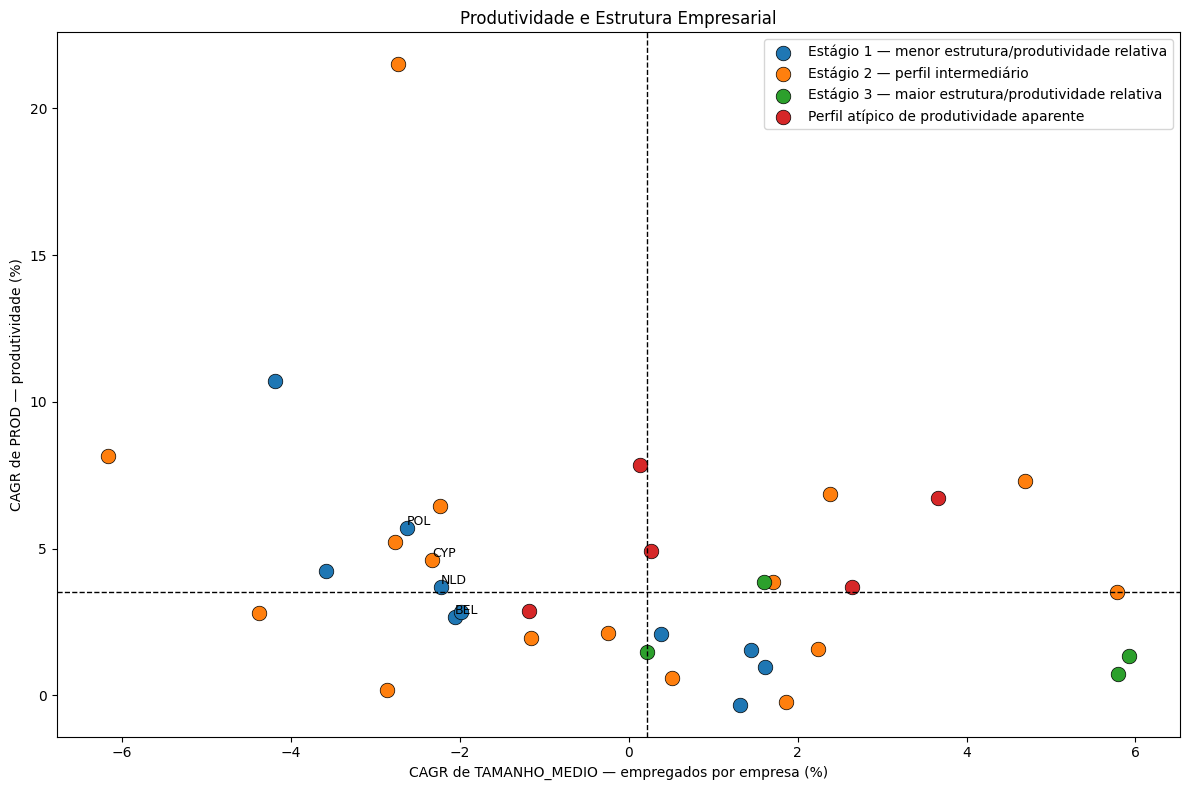

In [16]:
lim_tamanho = df_conv["CAGR_TAMANHO_MEDIO"].median()

fig, ax = plt.subplots(figsize=(12, 8))

for estagio, grupo in df_conv.groupby("Estagio"):
    ax.scatter(
        grupo["CAGR_TAMANHO_MEDIO"],
        grupo["CAGR_PROD"],
        s=110,
        edgecolor="black",
        linewidth=0.5,
        label=nomes_estagio.get(estagio, f"Estágio {estagio}")
    )

    for _, row in grupo.iterrows():
        if row["Pais"] == PAIS_REFERENCIA or row["Pais"] in top_twins_estrutural["Twin"].head(5).tolist():
            ax.text(
                row["CAGR_TAMANHO_MEDIO"],
                row["CAGR_PROD"],
                row["Pais"],
                fontsize=9,
                ha="left",
                va="bottom"
            )

ax.axhline(lim_prod, color="black", linestyle="--", linewidth=1)
ax.axvline(lim_tamanho, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("CAGR de TAMANHO_MEDIO — empregados por empresa (%)")
ax.set_ylabel("CAGR de PROD — produtividade (%)")
ax.set_title("Produtividade e Estrutura Empresarial")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

---

## 9. Sumário metodológico da versão aprimorada

Esta tabela resume as principais decisões metodológicas do notebook.

| Etapa | Ajuste aplicado | Justificativa |
|---|---|---|
| Base de modelagem | `log1p + RobustScaler` | Reduz assimetria e diminui influência de valores extremos |
| Ajuste da escala | scaler ajustado sem países marcados como outliers de produtividade | Evita que perfis extremos comprimam a escala dos demais países |
| K-Means | trajetórias robustas país × ano × indicador | Captura semelhança geral de escala e estrutura |
| DTW | `PROD` e `TAMANHO_MEDIO` em escala robusta | Foca a trajetória estrutural do mercado |
| Hierárquico DTW | `average-linkage` | Mais adequado para matriz de distância DTW pré-computada |
| Comparação de clusters | ARI e NMI | Compara clusterizações sem depender dos números arbitrários dos rótulos |
| Maturidade | três estágios interpretáveis entre não outliers + grupo atípico separado | Evita o colapso excessivo em poucos grupos e melhora a leitura analítica |
| Market Twin | versão ampla e versão estrutural | Mostra que a semelhança depende da definição das variáveis usadas |
| Convergência | CAGR em valores reais | Permite comparar crescimento médio anual mantendo interpretação econômica |

## Como interpretar o notebook como um todo

Este notebook não deve ser lido como uma previsão fechada do futuro da Polônia ou de qualquer outro país. Ele é uma análise exploratória de similaridade entre mercados de software. Seu objetivo é ajudar a identificar padrões, trajetórias e referências históricas.

A principal contribuição é mostrar que existem diferentes formas de comparar mercados:

```text
comparação ampla → considera escala e estrutura
comparação estrutural → considera produtividade e tamanho médio das empresas
```

Por isso, os Market Twins podem mudar dependendo da perspectiva. Isso não é um problema; pelo contrário, é uma informação importante. Ela mostra que a definição de similaridade precisa estar alinhada ao objetivo da análise.

